<div style="border:2px solid #4A90E2; padding:15px; border-radius:8px; background-color:#f9f9f9;">
  <h2 style="color:#D0021B; text-align:center;">🔍 Business Problem</h2>
  <p style="color:#333; font-size:14px; line-height:1.6;">
Instagram wants to track customer behavior, usage patterns, and engagement within its application. The objective is to analyze how users interact with the platform, identify trends in customer activity, and measure engagement levels. This insight will help optimize features, improve user experience, and strengthen customer retention strategies.
  </p>
</div>

In [54]:
import pandas as pd
import seaborn as sns 
import numpy as np
from matplotlib import pyplot as plt

In [3]:
df=pd.read_csv('Instagram_Analytics.csv')

In [4]:
df

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,2024-11-30 09:25:22.954916,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,2025-08-15 09:25:22.954916,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,2025-09-11 09:25:22.954916,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,2025-09-18 09:25:22.954916,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,2025-03-21 09:25:22.954916,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,IG0029995,2024-12-18 09:25:22.954916,Video,46046,8354,3847,11095,597992,820688,1254,18,124,Reels Feed,8.45,Travel
29995,IG0029996,2025-05-05 09:25:22.954916,Carousel,67711,3266,458,12380,1908094,2218288,1427,4,310,Hashtags,3.78,Beauty
29996,IG0029997,2025-05-26 09:25:22.954916,Photo,52326,7328,3687,7619,1984066,2447893,713,4,223,Explore,2.90,Photography
29997,IG0029998,2025-08-02 09:25:22.954916,Carousel,158113,5890,2573,6329,1984709,2001092,1341,22,978,Explore,8.64,Technology


In [5]:
df.head () ## It will give us with the first top 10 records

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,2024-11-30 09:25:22.954916,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,2025-08-15 09:25:22.954916,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,2025-09-11 09:25:22.954916,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,2025-09-18 09:25:22.954916,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,2025-03-21 09:25:22.954916,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology


In [6]:
df.columns   ## df.columns will give us with the name of columns

Index(['post_id', 'upload_date', 'media_type', 'likes', 'comments', 'shares',
       'saves', 'reach', 'impressions', 'caption_length', 'hashtags_count',
       'followers_gained', 'traffic_source', 'engagement_rate',
       'content_category'],
      dtype='object')

## Data Preprocessing 

In [7]:
df.shape    ## Shape of the dataset consist of number of rows and columns in an dataset

(29999, 15)

In [11]:
df.isnull().sum()

post_id             0
upload_date         0
media_type          0
likes               0
comments            0
shares              0
saves               0
reach               0
impressions         0
caption_length      0
hashtags_count      0
followers_gained    0
traffic_source      0
engagement_rate     0
content_category    0
dtype: int64

In [16]:
df.duplicated()  ## Their is no duplicates values present in it so it returns the boolean value as false.

0        False
1        False
2        False
3        False
4        False
         ...  
29994    False
29995    False
29996    False
29997    False
29998    False
Length: 29999, dtype: bool

In [18]:
df.describe()

,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,engagement_rate
count,29999.000000,29999.000000,29999.000000,29999.000000,2.999900e+04,2.999900e+04,29999.000000,29999.000000,29999.000000,29999.000000
mean,99912.661789,5017.781426,2502.912564,7490.124637,9.965616e+05,1.246669e+06,1103.110904,14.887430,502.152805,14.419276
std,57905.967401,2888.404881,1448.320395,4352.546949,5.777906e+05,5.970924e+05,635.991308,9.005811,290.364038,29.660210
min,7.000000,0.000000,0.000000,0.000000,1.650000e+02,5.107000e+03,0.000000,0.000000,0.000000,0.120000
25%,49755.000000,2530.500000,1246.000000,3690.500000,4.936810e+05,7.469585e+05,555.000000,7.000000,251.000000,5.180000
50%,99580.000000,5042.000000,2498.000000,7483.000000,9.921810e+05,1.241026e+06,1100.000000,15.000000,501.000000,9.190000
75%,150225.000000,7518.000000,3768.000000,11294.000000,1.494798e+06,1.749264e+06,1656.000000,23.000000,755.000000,15.670000
max,200000.000000,10000.000000,5000.000000,15000.000000,1.999865e+06,2.497940e+06,2200.000000,30.000000,1000.000000,3259.820000


## EDA (Explatory data analysis)

In [28]:
## Actually we need to find that how many posts are their total :

df["post_id"].count() ## So 29999 post are shared in the instagram for that particular product

29999

In [9]:
df.groupby("content_category")["post_id"].count().sort_values(ascending=False) 
## From This we find that the most of the content is on photography which is 3035 posts 

content_category
Photography    3035
Fashion        3034
Technology     3025
Lifestyle      3017
Food           3010
Fitness        3004
Music          3003
Travel         2968
Beauty         2953
Comedy         2950
Name: post_id, dtype: int64

In [13]:
## Which content cateogry have more likes,reach,comment,saves
metrics_max_df = df.groupby("content_category").agg({
    "likes": "count",
    "comments": "count",
    "saves": "count",
    "reach": "count"
})
# Sort by one metric (e.g., likes) if needed
metrics_max_df = metrics_max_df.sort_values("likes", ascending=False)
print(metrics_max_df)
## As per the analysis The most of the customers are liking the Photography content:

                  likes  comments  saves  reach
content_category                               
Photography        3035      3035   3035   3035
Fashion            3034      3034   3034   3034
Technology         3025      3025   3025   3025
Lifestyle          3017      3017   3017   3017
Food               3010      3010   3010   3010
Fitness            3004      3004   3004   3004
Music              3003      3003   3003   3003
Travel             2968      2968   2968   2968
Beauty             2953      2953   2953   2953
Comedy             2950      2950   2950   2950


In [14]:
## Which content cateogry are not liking by the customers mostly:
df_min_metrics  = df.groupby("content_category").agg({
                 "likes" : "count",
                 "comments":"count",
                  "saves"  : "count",
                  "reach"  : "count"
})
metrics_min = df_min_metrics.sort_values("likes",ascending=True)
print(metrics_min)
## According to the analysis most of the  comdey content dont have much reach:

                  likes  comments  saves  reach
content_category                               
Comedy             2950      2950   2950   2950
Beauty             2953      2953   2953   2953
Travel             2968      2968   2968   2968
Music              3003      3003   3003   3003
Fitness            3004      3004   3004   3004
Food               3010      3010   3010   3010
Lifestyle          3017      3017   3017   3017
Technology         3025      3025   3025   3025
Fashion            3034      3034   3034   3034
Photography        3035      3035   3035   3035


In [15]:
## Which media_type as more likes :
df.groupby("media_type")["likes"].max().sort_values(ascending=False)

## Reel posts on Instagram receive 
## more likes than other content formats, 
##showing they are more effective at driving user engagement.

media_type
Reel        200000
Photo       199994
Video       199993
Carousel    199980
Name: likes, dtype: int64

In [34]:
## The followers gained from profiles :
df.groupby("traffic_source")["followers_gained"].mean().sort_values(ascending=False) .round(2)

traffic_source
Profile       511.14
External      502.77
Explore       502.75
Home Feed     502.54
Reels Feed    501.75
Hashtags      492.17
Name: followers_gained, dtype: float64

In [38]:
df.groupby("media_type")["caption_length"].count()

media_type
Carousel    7526
Photo       7435
Reel        7515
Video       7523
Name: caption_length, dtype: int64

In [45]:
a = df.pivot_table(
    index="media_type",
    values="caption_length",
    aggfunc="mean"
)

# Convert averages into percentage share of the total
a["percentage"] = (a["caption_length"] / a["caption_length"].sum() * 100).round(2)

print(a)



            caption_length  percentage
media_type                            
Carousel       1102.935291       25.00
Photo          1098.577001       24.90
Reel           1104.271058       25.03
Video          1106.608534       25.08


In [52]:
pivot_table = df.pivot_table(
    index="content_category",
    values="engagement_rate",
    aggfunc="mean"
)

# Round the values to 2 decimal places
pivot_table = pivot_table.round(2)

print(pivot_table)


                  engagement_rate
content_category                 
Beauty                      15.66
Comedy                      14.40
Fashion                     14.52
Fitness                     13.95
Food                        13.99
Lifestyle                   14.69
Music                       14.49
Photography                 14.82
Technology                  13.93
Travel                      13.76


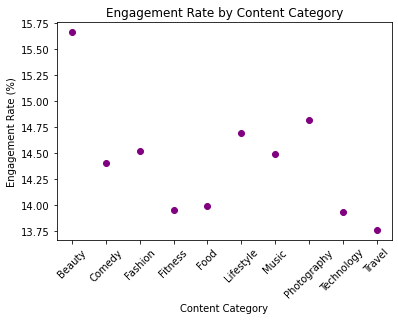

In [64]:
## visulasation :
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(
    x=pivot_table.index, 
    y=pivot_table["engagement_rate"], 
    color="purple"
)

plt.title("Engagement Rate by Content Category")
plt.xlabel("Content Category")
plt.ylabel("Engagement Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Conclusion :The content category beauty has avg mean of Enagement Rate 

## Conculsion :

As with the above conclusion we find that the photography content has higher likes,comments, shares etc but the avg enagement rate is high in beauty content why ? 

Here is the answer for that particular solution:of
Photography content: May attract the highest number of likes, comments, and shares overall.

Beauty content: Might have fewer total interactions, but if the audience (followers) is smaller, those interactions represent a larger proportion of the audience. 

The posts  for the photography are 3035 but the posts for the beauty content is less which is 2953 so the audience enagement rate is more .

In [66]:
# Correct way to calculate correlation
df[["followers_gained", "engagement_rate"]].corr()


,followers_gained,engagement_rate
followers_gained,1.000000,-0.001056
engagement_rate,-0.001056,1.000000


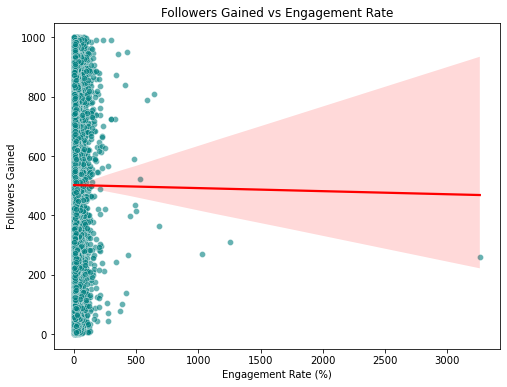

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df["engagement_rate"], 
    y=df["followers_gained"], 
    color="teal", 
    alpha=0.6
)

# Add regression line to show trend
sns.regplot(
    x=df["engagement_rate"], 
    y=df["followers_gained"], 
    scatter=False, 
    color="red"
)

plt.title("Followers Gained vs Engagement Rate")
plt.xlabel("Engagement Rate (%)")
plt.ylabel("Followers Gained")
plt.show()


In [69]:
# Ensure upload_date is datetime type
df["upload_date"] = pd.to_datetime(df["upload_date"])

# Extract only the date (drop the time)
df["upload_day"] = df["upload_date"].dt.date

# Group by date and sum interactions
summary = df.groupby("upload_day")[["likes", "comments", "shares", "saves"]].sum()

print(summary)



              likes  comments  shares   saves
upload_day                                   
2024-11-19  7461455    419973  186297  640646
2024-11-20  8687936    489716  239046  652512
2024-11-21  7777724    414510  231397  648130
2024-11-22  6553102    323882  165926  523702
2024-11-23  8676870    514181  207000  694702
...             ...       ...     ...     ...
2025-11-15  8545423    423986  204251  548235
2025-11-16  8469486    408115  201912  580698
2025-11-17  8070610    398221  166300  504624
2025-11-18  7468885    427598  192377  606186
2025-11-19  7169080    444531  201651  638017

[366 rows x 4 columns]


In [74]:
## which content have more hastag counts

df.groupby("content_category")["hashtags_count"].max()

content_category
Beauty         30
Comedy         30
Fashion        30
Fitness        30
Food           30
Lifestyle      30
Music          30
Photography    30
Technology     30
Travel         30
Name: hashtags_count, dtype: int64